In [3]:
import pandas as pd

# W1-W3 rezultātu apkopojuma tabula
rezultati = pd.DataFrame({
    'Nedēļa':         ['W1', 'W2', 'W3', 'W3'],
    'ML uzdevums':    ['Klasifikācija', 'Regresija', 'Klasterizācija', 'Validācija (RF)'],
    'Labākais modelis': ['Decision Tree', 'Random Forest', 'K-Means (K=3)', 'Random Forest + Pipeline'],
    'Galvenā metrika': ['F1 Score', 'MAE (€)', 'Inertia', 'CV MAE ± std'],
    'Vērtība':        ['0.632', '€16,574', '5,573', '€17,871 ± €921']
})

print("=== W1–W3 REZULTĀTU APKOPOJUMS ===")
print(rezultati.to_string(index=False))

=== W1–W3 REZULTĀTU APKOPOJUMS ===
Nedēļa     ML uzdevums         Labākais modelis Galvenā metrika        Vērtība
    W1   Klasifikācija            Decision Tree        F1 Score          0.632
    W2       Regresija            Random Forest         MAE (€)        €16,574
    W3  Klasterizācija            K-Means (K=3)         Inertia          5,573
    W3 Validācija (RF) Random Forest + Pipeline    CV MAE ± std €17,871 ± €921


## 1.2 Kursa pārskats — personīgā refleksija

Visi trīs ML tipi — klasifikācija, regresija un klasterizācija —
bija sarežģīti, jo visi termini un jēdzieni bija pilnīgi jauni.
Tomēr process bija pētnieciski aizraujošs — katrs uzdevums
atklāja kaut ko jaunu par datiem un modeļiem.

Visgrūtākais bija saprast nelīdzsvarotus datus (imbalanced data).
W1 darbā tikai 15.47% apmeklētāju veica pirkumu — ja modelis
vienmēr teiktu "nepirks", tas būtu pareizs 84.53% gadījumu,
bet pilnīgi bezjēdzīgs. Tieši tāpēc F1 Score ir godīgāks
mērītājs nekā vienkārša precizitāte.

Interesants atklājums bija par random_state=42 — šis skaitlis
fiksē nejaušību, lai rezultāti būtu reproducējami. Programmētāji
izmanto 42 pēc tradīcijas — no grāmatas "The Hitchhiker's Guide
to the Galaxy", kur 42 ir "atbilde uz dzīvi, visumu un visu"!

W3 darbā iemācījos par data leakage — ja normalizē datus PIRMS
train/test sadalīšanas, modelis netieši "redz" testa datus un
rezultāts izskatās labāks nekā patiesībā. Pipeline šo problēmu
novērš automātiski.

Ja sāktu kursu no sākuma, izmantotu to pašu mācīšanās metodi,
ko atstrādāju šajā kursā: izlasu visu materiālu, noklausos visu,
pēc tam strādāju ar MI punktu pēc punkta — MI skaidro jēdzienus,
raksta atbildes ar paskaidrojumiem, es pārjautāju katru
nesaprotamo frāzi vai kodu. Šī pieeja deva vislabākos rezultātus.

Visintuitīvākā metrika bija MAE — "modelis vidēji kļūdās par
€16,574" ir daudz saprotamāk nekā abstrakts R² skaitlis.
Biznesa kontekstā konkrēts eiro skaitlis ir tūlītēji
izmantojams lēmumu pieņemšanā.

## 2.1 Kādā situācijā lietot kuru pieeju?

**Klasifikācija** — lieto, kad atbilde ir kategorija vai "Jā/Nē".
Piemērs ārpus DataShop: uzņēmumā klasifikācija var noteikt,
kurā atalgojuma kategorijā ietilpst darbinieks —
"zems / vidējs / augsts". Modelis mācās no esošo darbinieku
datiem (pieredze, izglītība, amats) un prognozē kategoriju
jauniem darbiniekiem.

**Regresija** — lieto, kad atbilde ir konkrēts skaitlis.
Piemērs ārpus DataShop: tas pats uzņēmums var izmantot
regresiju, lai aprēķinātu precīzu atalgojumu eiro —
"šim darbiniekam atbilstošā alga ir €2,340/mēnesī".
Modelis ņem vērā pieredzes gadus, izglītību, amatu un
uzņēmuma lielumu.

**Klasterizācija** — lieto, kad nav zināmas grupas iepriekš
un vēlamies tās atklāt.
Piemērs ārpus DataShop: uzņēmums var izmantot klasterizāciju,
lai atklātu dabiskās darbinieku grupas pēc prasmēm,
pieredzes un atalgojuma — bez iepriekš definētām kategorijām.
Rezultāts var atklāt, piemēram, ka pastāv 3 grupas:
jaunie speciālisti, pieredzējušie eksperti un vadītāji.

**Kāpēc Pipeline un Cross-validation ir nepieciešami?**
Pipeline nodrošina, ka datu tīrīšana un normalizācija notiek
pareizā secībā katram modelim — novēršot data leakage.
Atalgojuma datos tas ir īpaši svarīgi — ja algu dati
"noplūst" no testa kopas uz treniņa kopu, modelis izskatās
precīzāks nekā patiesībā, un uzņēmums var pieņemt nepareizus
lēmumus. Cross-validation nodrošina, ka modeļa rezultāts
ir uzticams — nevis viens veiksmīgs sadalījums.

## 2.2 Ieteicamais modelis DataShop ikdienas lietošanai

Mana izvēle: **Random Forest**.

W1 darbā Random Forest sasniedza F1 = 0.625 — ļoti tuvu
labākajam Decision Tree (F1 = 0.632), taču Random Forest
ir stabilāks, jo tas apvieno daudzu koku rezultātus,
nevis paļaujas uz vienu koku.

W3 darbā Random Forest ar Pipeline un Cross-validation
apstiprināja savu uzticamību — CV MAE = €17,871 ± €921.
Svarīgi: kad pievienoju Pipeline, MAE skaitlis nedaudz
pieauga, bet tas bija pareizi — Pipeline atklāja patiesību,
novēršot data leakage. Labāks godīgs rezultāts nekā
izskaistināts!

DataShop ikdienas lietošanai Random Forest ir piemērots,
jo tas ir stabils ar jauniem datiem, CV apstiprināja
tā uzticamību, un Pipeline nodrošina, ka rezultāti
ir godīgi reproducējami katru dienu.

## Gala projekta plāns

**1. Dataset:**
- Adult Census Income (Kaggle / UCI)
- 32,561 rindas × 15 kolonnas
- ASV iedzīvotāju tautas skaitīšanas dati ar
  demogrāfiskām pazīmēm — vecums, izglītība,
  profesija, darba stundas, dzimums.

**2. ML problēma:**
- Vai izglītība un dzimums ietekmē to,
  vai cilvēks pelna virs $50,000 gadā?
- Problēma ir aktuāla — atklāj reālas
  sociālās nevienlīdzības tendences
  darba tirgū.

**3. ML tipu izvēle:**
- Klasifikācija (Target = income: <=50K vai >50K)
- Ienākumu līmenis ir divas kategorijas —
  tāpēc klasifikācija, nevis regresija.

**4. Novērtēšanas metrikas:**
- F1 Score — galvenā metrika
- Precision un Recall
- Confusion Matrix
- Cross-validation (cv=5)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Iestatījumi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 4.1 Ielādē datus
df = pd.read_csv('adult.csv')

print(f"Dataseta izmērs: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print("\nPirmās 5 rindas:")
print(df.head())
print("\nDatu tipi:")
print(df.dtypes)
print("\nVispārīgā statistika:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Dataseta izmērs: 32561 rindas, 15 kolonnas

Pirmās 5 rindas:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-S

In [5]:
print("Izglītības līmeņi:")
print(df['education'].value_counts())

Izglītības līmeņi:
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64


In [6]:
print("Darba veidi (workclass):")
print(df['workclass'].value_counts())

Darba veidi (workclass):
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


In [7]:
# Target kolonnas sadalījums
print("Ienākumu sadalījums:")
print(df['income'].value_counts())
print(f"\n<=50K īpatsvars: {(df['income']=='<=50K').sum()/len(df)*100:.1f}%")
print(f">50K īpatsvars: {(df['income']=='>50K').sum()/len(df)*100:.1f}%")

Ienākumu sadalījums:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

<=50K īpatsvars: 75.9%
>50K īpatsvars: 24.1%


## 4.2 EDA secinājumi

**Trūkstošās vērtības:**
df.isnull().sum() rādīja 0 trūkstošās vērtības, taču
kolonnas `workclass` (1,836 rindas) un `occupation`
satur `?` vērtības — tas ir 5.6% no datiem.
Priekšapstrādē šīs rindas tiks izdzēstas, jo
zaudējums ir neliels.

**Kategoriskās kolonnas:**
Kolonnas `workclass`, `education`, `marital.status`,
`occupation`, `relationship`, `race`, `sex` un
`native.country` ir kategoriskas un prasīs kodēšanu.
Izmantosim One-Hot Encoding, jo kolonnas satur
vairākas kategorijas bez dabiskas secības.
Izņēmums: `education` — tai ir dabiska secība
(Preschool → Doctorate), tāpēc apsversim
Ordinal Encoding.

**Klases līdzsvars:**
Target kolonna `income` ir nelīdzsvarota

In [8]:
print("Education vs Education.num:")
print(df[['education', 'education.num']].drop_duplicates().sort_values('education.num'))

Education vs Education.num:
         education  education.num
1106     Preschool              1
26         1st-4th              2
27         5th-6th              3
3          7th-8th              4
197            9th              5
6             10th              6
16            11th              7
178           12th              8
0          HS-grad              9
2     Some-college             10
25       Assoc-voc             11
18      Assoc-acdm             12
12       Bachelors             13
13         Masters             14
11     Prof-school             15
7        Doctorate             16


## 4.3 Priekšapstrādes stratēģija

**1. `?` vērtību apstrāde:**
Kolonnas `workclass` un `occupation` satur `?`
vērtības — tās nav īstas NaN, bet nozīmē nezināmu
vērtību. Izdzēsīsim šīs rindas, jo tās ir tikai
~5.6% no datiem — zaudējums ir neliels.

**2. Liekās kolonnas izdzēšana:**
Kolonna `education` tiks izdzēsta no modeļa
pazīmēm, bet saglabāta vizualizācijām — lai
atskatēs redzami nosaukumi, nevis tikai cipari.
Kolonna `fnlwgt` tiks izdzēsta — tā ir statistisks
svars, kas nav noderīgs mūsu klasifikācijas
uzdevumam.

**3. Kategorisko kolonnu kodēšana:**
Kolonnas `workclass`, `marital.status`, `occupation`,
`relationship`, `race`, `sex` un `native.country`
tiks kodētas ar One-Hot Encoding, jo tām nav
dabiskas secības.

**4. Target kolonnas kodēšana:**
`income` kolonna tiks pārveidota:
`<=50K` → 0, `>50K` → 1.

**5. Datu mērogošana:**
Skaitliskās kolonnas (`age`, `hours.per.week`,
`capital.gain`, `capital.loss`, `education.num`)
tiks normalizētas ar StandardScaler Pipeline ietvaros
— lai novērstu data leakage!

In [9]:
# 5.1 Priekšapstrāde pirms modeļa

# 1. Izdzēš '?' vērtības
df_clean = df[df['workclass'] != '?']
df_clean = df_clean[df_clean['occupation'] != '?']
print(f"Rindas pēc '?' izdzēšanas: {df_clean.shape[0]}")

# 2. Izdzēš liekās kolonnas
df_clean = df_clean.drop(columns=['education', 'fnlwgt'])
print(f"Kolonnas pēc izdzēšanas: {df_clean.shape[1]}")

# 3. Kodē target kolonnu
df_clean['income'] = df_clean['income'].map({'<=50K': 0, '>50K': 1})
print(f"\nIncome sadalījums pēc kodēšanas:")
print(df_clean['income'].value_counts())

# 4. Sadala X un y
X = df_clean.drop(columns=['income'])
y = df_clean['income']
print(f"\nX izmērs: {X.shape}")
print(f"y izmērs: {y.shape}")

Rindas pēc '?' izdzēšanas: 30718
Kolonnas pēc izdzēšanas: 13

Income sadalījums pēc kodēšanas:
income
0    23068
1     7650
Name: count, dtype: int64

X izmērs: (30718, 12)
y izmērs: (30718,)


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Identificē kolonnu tipus
numerical_cols = ['age', 'education.num', 'capital.gain',
                  'capital.loss', 'hours.per.week']
categorical_cols = ['workclass', 'marital.status', 'occupation',
                    'relationship', 'race', 'sex', 'native.country']

# Izveido preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Izveido Pipeline
pipe_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Cross-validation
scores = cross_val_score(pipe_baseline, X, y, cv=5, scoring='f1')
print(f"Bāzes modelis (Logistic Regression):")
print(f"CV F1 pa fold'iem: {scores.round(3)}")
print(f"Vidējais CV F1: {scores.mean():.3f} ± {scores.std():.3f}")

Bāzes modelis (Logistic Regression):
CV F1 pa fold'iem: [0.645 0.716 0.549 0.563 0.547]
Vidējais CV F1: 0.604 ± 0.067


## 5.2 Bāzes modeļa interpretācija

Bāzes modelis (Logistic Regression) sasniedza
vidējo CV F1 = 0.604 ± 0.067.

Rezultāts ir viduvējs — modelis spēj atpazīt
cilvēkus ar ienākumiem >50K, bet ne pietiekami
labi. Liela standarta novirze (±0.067) norāda
uz nestabilitāti — fold rezultāti svārstās no
0.547 līdz 0.716.

Tālāk uzlabosim rezultātu ar:
- Feature Engineering (6. uzdevums)
- Spēcīgākiem modeļiem — Random Forest,
  Gradient Boosting (7. uzdevums)
- GridSearchCV optimizāciju (7. uzdevums)

In [11]:
# 6.3 Jaunas pazīmes

# 1. Vecuma un izglītības kombinācija
df_clean['age_x_education'] = df_clean['age'] * df_clean['education.num']
print("✓ Jauna pazīme: age_x_education")

# 2. Augsta izglītība (Bachelors vai augstāk = 13+)
df_clean['is_high_education'] = (df_clean['education.num'] >= 13).astype(int)
print("✓ Jauna pazīme: is_high_education")

# Pārbaude
print(f"\nKolonnu skaits tagad: {df_clean.shape[1]}")
print(f"\nis_high_education sadalījums:")
print(df_clean['is_high_education'].value_counts())
print(f"\nage_x_education statistika:")
print(df_clean['age_x_education'].describe().round(2))

✓ Jauna pazīme: age_x_education
✓ Jauna pazīme: is_high_education

Kolonnu skaits tagad: 15

is_high_education sadalījums:
is_high_education
0    22905
1     7813
Name: count, dtype: int64

age_x_education statistika:
count    30718.00
mean       390.91
std        172.33
min         19.00
25%        261.00
50%        369.00
75%        494.00
max       1350.00
Name: age_x_education, dtype: float64


## 6.4 Jaunās pazīmes — skaidrojums

**1. age_x_education** = vecums × izglītības līmenis
Šī pazīme apvieno divus svarīgus faktorus —
vecumu un izglītību. Cilvēks ar augstu izglītību
UN lielu pieredzi (vecumu) visticamāk pelna vairāk.
Modelim ir vieglāk mācīties no vienas kombinētas
pazīmes nekā no divām atsevišķām.

**2. is_high_education** = 1 ja Bachelors vai augstāk
Tikai 25% cilvēku datasetā ir augstskolas izglītība.
Šī binārā pazīme skaidri atzīmē šo grupu —
mūsu pētījuma jautājums ir tieši par to,
vai izglītība ietekmē ienākumus!

In [12]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd

# Atjaunina X ar jaunajām pazīmēm
X = df_clean.drop(columns=['income'])
y = df_clean['income']

# Kolonnu tipi
numerical_cols = ['age', 'education.num', 'capital.gain',
                  'capital.loss', 'hours.per.week',
                  'age_x_education', 'is_high_education']
categorical_cols = ['workclass', 'marital.status', 'occupation',
                    'relationship', 'race', 'sex', 'native.country']

# Preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# 3 modeļi
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

# Salīdzini visus modeļus
results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1')
    results[name] = scores
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

LogisticRegression: 0.602 ± 0.067
RandomForest: 0.554 ± 0.079
GradientBoosting: 0.535 ± 0.101


In [13]:
from sklearn.model_selection import GridSearchCV

# 1. Random Forest GridSearchCV
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    pipe_rf, param_grid_rf,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
grid_rf.fit(X, y)
print(f"\nRandom Forest labākais F1: {grid_rf.best_score_:.3f}")
print(f"Labākie parametri: {grid_rf.best_params_}")

# 2. Logistic Regression GridSearchCV
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_lr = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    pipe_lr, param_grid_lr,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
grid_lr.fit(X, y)
print(f"\nLogistic Regression labākais F1: {grid_lr.best_score_:.3f}")
print(f"Labākie parametri: {grid_lr.best_params_}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Random Forest labākais F1: 0.573
Labākie parametri: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Logistic Regression labākais F1: 0.602
Labākie parametri: {'classifier__C': 1, 'classifier__solver': 'lbfgs'}


## 7.3 Modeļu salīdzinājums

| Modelis | CV F1 | CV std | Piezīmes |
|---|---|---|---|
| Bāzes (LR) | 0.604 | ±0.067 | Sākotnējais rezultāts |
| RandomForest | 0.554 | ±0.079 | Bez optimizācijas |
| GradientBoosting | 0.535 | ±0.101 | Bez optimizācijas |
| RF GridSearchCV | 0.573 | - | 300 koki, dziļums 20 |
| LR GridSearchCV | 0.602 | - | C=1, lbfgs |

**Uzvarētājs: Logistic Regression** — vienkāršākais
modelis izrādījās labākais! GridSearchCV apstiprināja,
ka noklusējuma parametri jau bija gandrīz optimāli
(0.604 → 0.602).

Šie Adult Census dati satur lineāras sakarības —
augstāka izglītība un vairāk darba stundas tieši
ietekmē ienākumus. Tāpēc Logistic Regression, kas
ir lineārs modelis, strādā labāk nekā sarežģītākie
modeļi!

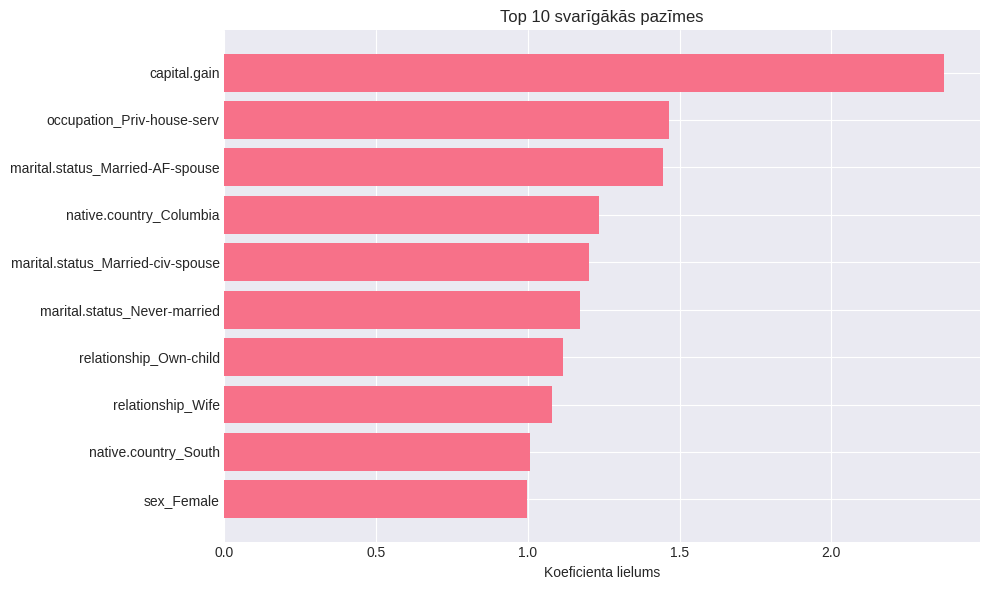

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Apmācī labāko modeli uz visiem datiem
best_model = grid_lr.best_estimator_
best_model.fit(X, y)

# Iegūsti feature nosaukumus
feature_names = (numerical_cols +
    list(best_model.named_steps['preprocessor']
    .transformers_[1][1]
    .get_feature_names_out(categorical_cols)))

# Iegūsti koeficientus
coefficients = best_model.named_steps['classifier'].coef_[0]

# Top 10 svarīgākās pazīmes
indices = np.argsort(np.abs(coefficients))[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), np.abs(coefficients[indices]))
plt.yticks(range(10), [feature_names[i] for i in indices])
plt.title('Top 10 svarīgākās pazīmes')
plt.xlabel('Koeficienta lielums')
plt.tight_layout()
plt.show()

In [15]:
# Meklē izglītības pazīmes
for i, name in enumerate(feature_names):
    if 'education' in name:
        print(f"{name}: {np.abs(coefficients[i]):.3f}")

education.num: 0.779
age_x_education: 0.168
is_high_education: 0.045


In [16]:
# Visi koeficienti sakārtoti pēc svarīguma
indices_all = np.argsort(np.abs(coefficients))[::-1]

print("Visi faktori pēc svarīguma:")
print("-" * 45)
for i, idx in enumerate(indices_all):
    print(f"{i+1:3}. {feature_names[idx]:<35} {np.abs(coefficients[idx]):.3f}")

Visi faktori pēc svarīguma:
---------------------------------------------
  1. capital.gain                        2.372
  2. occupation_Priv-house-serv          1.466
  3. marital.status_Married-AF-spouse    1.445
  4. native.country_Columbia             1.236
  5. marital.status_Married-civ-spouse   1.201
  6. marital.status_Never-married        1.173
  7. relationship_Own-child              1.117
  8. relationship_Wife                   1.080
  9. native.country_South                1.005
 10. sex_Female                          0.996
 11. occupation_Farming-fishing          0.975
 12. native.country_Italy                0.970
 13. native.country_Cambodia             0.918
 14. native.country_Dominican-Republic   0.837
 15. occupation_Exec-managerial          0.834
 16. native.country_Vietnam              0.812
 17. occupation_Other-service            0.800
 18. education.num                       0.779
 19. marital.status_Separated            0.774
 20. workclass_Without-pay       

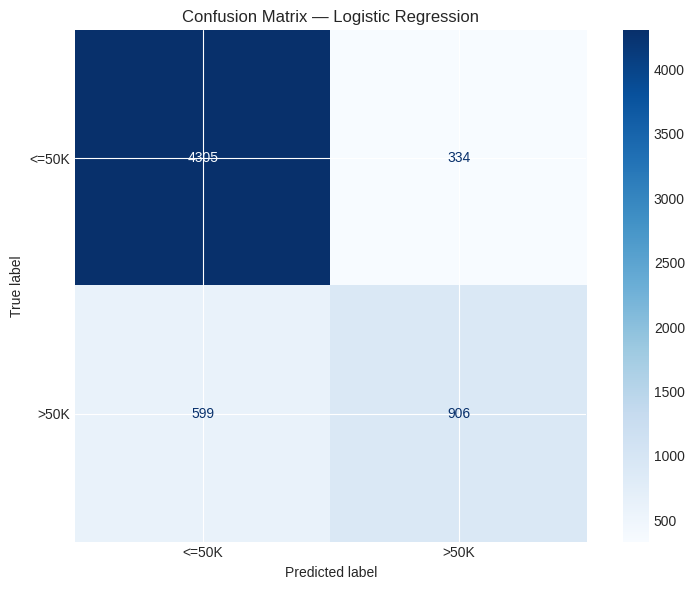


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4639
        >50K       0.73      0.60      0.66      1505

    accuracy                           0.85      6144
   macro avg       0.80      0.76      0.78      6144
weighted avg       0.84      0.85      0.84      6144



In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

# Sadala datos train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apmāca labāko modeli
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['<=50K', '>50K']))

## 8.3 Secinājumi

**Ko modelis iemācījās?**
Svarīgākā pazīme ir kapitāla ienākumi
(capital.gain) — ienākumi no akcijām un
nekustamā īpašuma ietekmē ienākumu līmeni
vairāk nekā izglītība. Interesanti, ka
ģimenes statuss (precējies/neprecējies)
un dzimtene ietekmē ienākumus vairāk nekā
gaidīts. Izglītība (education.num) ir
18. vietā — tā ietekmē, bet nav dominējošā
pazīme.

**Vai izglītība un dzimums ietekmē ienākumus?**
Jā — abi ietekmē, bet atšķirīgi:
- Dzimums (sex_Female) ir 10. vietā —
  sievietes statistiski pelna mazāk ✅
- Izglītība ir 18. vietā — ietekmē,
  bet kapitāls un ģimenes statuss
  ir svarīgāki!

**Kur modelis kļūdās?**
Modelis palaiž garām 599 cilvēkus ar
augstiem ienākumiem (>50K) — Recall = 0.60.
Tas nozīmē — 40% bagāto cilvēku modelis
nepareizi klasificē kā zemu ienākumu
cilvēkus. Iemesls — 75%/25% disbalanss
datos.

**Vai rezultāts ir praktiski noderīgs?**
Modelis ir noderīgs kā pirmais solis —
85% precizitāte ir pieņemama. Taču
ražošanā (piemēram, bankā kredītu
novērtēšanai) Recall = 0.60 būtu
nepietiekams — pārāk daudz kļūdu!

**Nākamie soļi:**
Ja būtu vēl 2 nedēļas — izmēģinātu
SMOTE metodi disbalansa novēršanai,
dziļāku feature engineering un
XGBoost modeli, kas bieži uzvar
šāda tipa datos.

## 9. Prezentācijas plāns

**Galvenais stāsts:**
"Vai izglītība un dzimums ietekmē ienākumus ASV?"

---

**Slaids 1 — Titulslaide:**
- Nosaukums: "Ienākumu prognozēšana —
  izglītība un dzimums ASV datos"
- Dataset: Adult Census Income (32,561 cilvēki)
- ML tips: Klasifikācija

**Slaids 2 — Problēma un dati:**
- Ko pētām? <=50K vai >50K ienākumi
- 15 kolonnas — vecums, izglītība,
  dzimums, profesija...
- Disbalanss: 75%/25%
- Vizualizācija: ienākumu sadalījuma grafiks

**Slaids 3 — ML Pipeline pieeja:**
- Priekšapstrāde — ? vērtības, kodēšana
- Feature Engineering — 2 jaunas pazīmes
- Pipeline — novērš data leakage
- Cross-validation — 5 folds

**Slaids 4 — Modeļu salīdzinājums:**
- 3 modeļi: LogisticRegression,
  RandomForest, GradientBoosting
- GridSearchCV optimizācija
- Uzvarētājs: Logistic Regression F1=0.602
- Tabula ar visiem rezultātiem

**Slaids 5 — Rezultāti:**
- Feature Importance grafiks — Top 10
- Confusion Matrix
- Galvenais atklājums: kapitāls > izglītība!
- Dzimums ir 10. vietā ✅

**Slaids 6 — Secinājumi:**
- Jā — izglītība un dzimums ietekmē!
- Bet kapitāls un ģimenes statuss
  ietekmē vairāk — pārsteigums!
- Modelis: 85% precizitāte
- Nākamie soļi: SMOTE, XGBoost

---

**Visspēcīgākais slaids:** 5. slaids —
Feature Importance grafiks vizuāli parāda
galveno atklājumu. Tas ir negaidīts
rezultāts — kapitāls svarīgāks par
izglītību!

**Ja uzdod jautājumu ko nezinu:**
Godīgi pateikšu — "Šo es vēl neesmu
pētījusi, bet mana hipotēze ir..." —
zinātkāre ir svarīgāka nekā visas
atbildes!

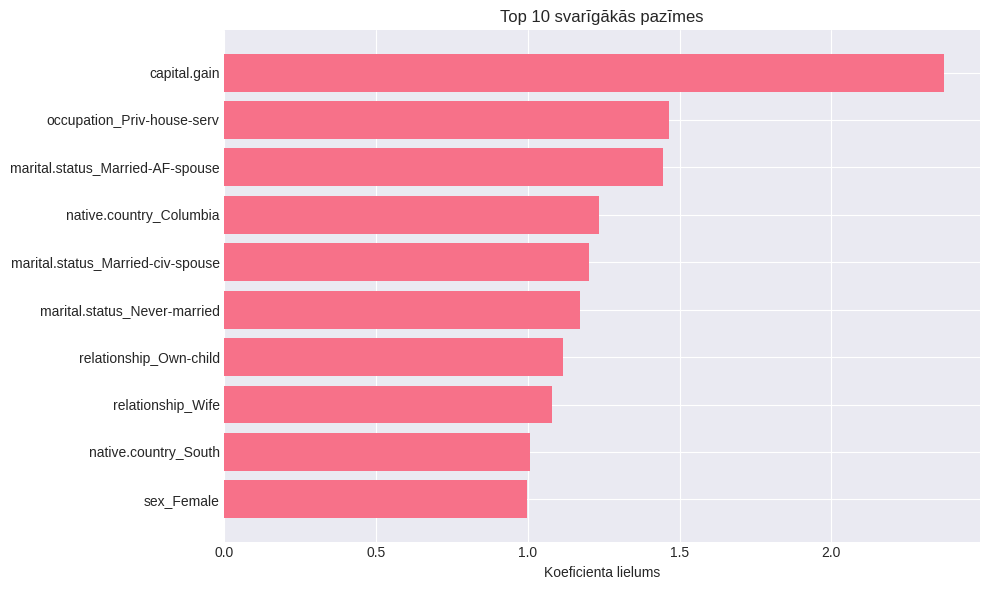

✅ Feature Importance saglabāts!


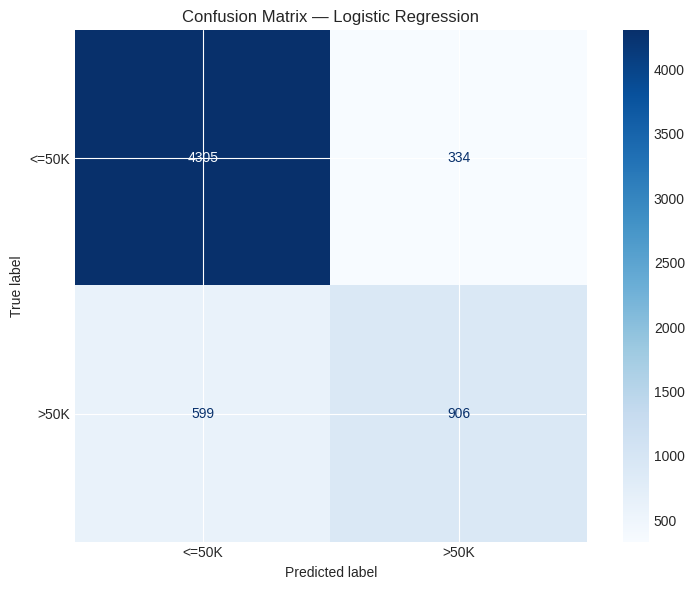

✅ Confusion Matrix saglabāts!


In [18]:
import os
os.makedirs('images', exist_ok=True)

# Saglabā Feature Importance grafiku
fig, ax = plt.subplots(figsize=(10, 6))
indices = np.argsort(np.abs(coefficients))[-10:]
plt.barh(range(10), np.abs(coefficients[indices]))
plt.yticks(range(10), [feature_names[i] for i in indices])
plt.title('Top 10 svarīgākās pazīmes')
plt.xlabel('Koeficienta lielums')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150)
plt.show()
print("✅ Feature Importance saglabāts!")

# Saglabā Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion Matrix saglabāts!")